<a href="https://colab.research.google.com/github/2521812022/Parcial4_CorenaGomez_2521812022/blob/main/Notebooks/Correlaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 2: Análisis de Correlación (Reglas de Correlación)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# Cargar el archivo CSV normal (separado por comas por defecto)
url_asociacion = "https://raw.githubusercontent.com/2521812022/Parcial4_CorenaGomez_2521812022/refs/heads/main/clave_C_correlacion.csv"
df_aso = pd.read_csv(url_asociacion)

# Mostrar las primeras filas del dataset
print(df_aso.head())

  cliente_id  edad  ingresos_mensuales  frecuencia_compra  ticket_promedio  \
0    C-C0001    26                 924                  6            44.94   
1    C-C0002    43                1015                  7            46.21   
2    C-C0003    23                 462                  3            37.50   
3    C-C0004    32                1410                  7            93.28   
4    C-C0005    18                1282                 11            41.51   

   satisfaccion  reclamos  uso_app  tiempo_respuesta  consumo_total  
0          7.54         1        5             23.30         290.84  
1          8.56         1        6             14.92         427.26  
2          6.75         3        4             36.34         145.63  
3          7.15         2        8             25.53         623.29  
4          8.73         1        8             23.25         531.66  


## 1. Cargar el archivo CSV
Importamos los datos de las métricas de los clientes y mostramos su estructura inicial.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo CSV desde GitHub (Este archivo viene separado por comas)
url_correlacion = "https://raw.githubusercontent.com/2521812022/Parcial4_CorenaGomez_2521812022/refs/heads/main/clave_C_correlacion.csv"
df_corr = pd.read_csv(url_correlacion)

# Mostrar las primeras filas del dataset
print(df_corr.head())

  cliente_id  edad  ingresos_mensuales  frecuencia_compra  ticket_promedio  \
0    C-C0001    26                 924                  6            44.94   
1    C-C0002    43                1015                  7            46.21   
2    C-C0003    23                 462                  3            37.50   
3    C-C0004    32                1410                  7            93.28   
4    C-C0005    18                1282                 11            41.51   

   satisfaccion  reclamos  uso_app  tiempo_respuesta  consumo_total  
0          7.54         1        5             23.30         290.84  
1          8.56         1        6             14.92         427.26  
2          6.75         3        4             36.34         145.63  
3          7.15         2        8             25.53         623.29  
4          8.73         1        8             23.25         531.66  


## 2. Identificar variables numéricas
El análisis de correlación (Pearson) requiere variables numéricas. Vamos a identificar con cuáles columnas podemos trabajar.

In [ ]:
# Filtrar y mostrar únicamente las columnas numéricas (enteros o decimales)
variables_numericas = df_corr.select_dtypes(include=['int64', 'float64']).columns
print("Variables numéricas identificadas para la correlación:")
for var in variables_numericas:
    print(f"- {var}")

Variables numéricas identificadas para la correlación:
- edad
- ingresos_mensuales
- frecuencia_compra
- ticket_promedio
- satisfaccion
- reclamos
- uso_app
- tiempo_respuesta
- consumo_total


## 3. Revisar datos nulos, atípicos y consistencia general
Aplicaremos la validación de calidad. Separaremos la data limpia de los errores y aplicaremos el criterio de **Media +/- 2 Desviaciones Estándar** para identificar si hay atípicos.

In [ ]:
print("--- 1. Revisión de Valores Nulos y Duplicados ---")
print(df_corr.isnull().sum())
print(f"\nCantidad de registros duplicados: {df_corr.duplicated().sum()}")

# 2. Consistencia: Separar data limpia y aislar registros con errores (nulos)
filas_con_nulos = df_corr[df_corr.isnull().any(axis=1)]
df_errores_corr = filas_con_nulos.copy()
df_errores_corr['motivo_error'] = 'Valores incompletos (nulos) en métricas clave'

df_limpio_corr = df_corr.dropna().copy()

print("\n--- 2. Detección de Valores Atípicos (Data Limpia) ---")
# Criterio: Límite Inferior = Media - 2*SD, Límite Superior = Media + 2*SD
for col in variables_numericas:
    media = df_limpio_corr[col].mean()
    desv = df_limpio_corr[col].std()
    lim_inf = media - 2 * desv
    lim_sup = media + 2 * desv

    atipicos = df_limpio_corr[(df_limpio_corr[col] < lim_inf) | (df_limpio_corr[col] > lim_sup)]
    print(f"{col}: {len(atipicos)} atípicos detectados.")

# Nota de negocio: Conservamos los atípicos en el dataset limpio porque un cliente
# con "consumo_total" muy alto es un cliente VIP real, no un error de sistema.

# 3. Exportar los archivos para trazabilidad
df_limpio_corr.to_csv('clave_C_correlacion_final_limpio.csv', index=False)
if len(df_errores_corr) > 0:
    df_errores_corr.to_csv('clave_C_correlacion_errores.csv', index=False)

print("\n--- 3. Archivos Exportados ---")
print(f"Data Limpia: {len(df_limpio_corr)} registros.")
print(f"Data con Errores: {len(df_errores_corr)} registros aislados.")

--- 1. Revisión de Valores Nulos y Duplicados ---
cliente_id            0
edad                  0
ingresos_mensuales    0
frecuencia_compra     0
ticket_promedio       1
satisfaccion          1
reclamos              0
uso_app               0
tiempo_respuesta      1
consumo_total         0
dtype: int64

Cantidad de registros duplicados: 1

--- 2. Detección de Valores Atípicos (Data Limpia) ---
edad: 4 atípicos detectados.
ingresos_mensuales: 10 atípicos detectados.
frecuencia_compra: 3 atípicos detectados.
ticket_promedio: 13 atípicos detectados.
satisfaccion: 12 atípicos detectados.
reclamos: 15 atípicos detectados.
uso_app: 8 atípicos detectados.
tiempo_respuesta: 6 atípicos detectados.
consumo_total: 10 atípicos detectados.

--- 3. Archivos Exportados ---
Data Limpia: 228 registros.
Data con Errores: 3 registros aislados.


## 4. Matriz de Correlación y Mapa de Calor
Calculamos el coeficiente de correlación de Pearson sobre el dataset limpio y generamos el gráfico para interpretarlo visualmente.

--- Matriz de Correlación ---
                    edad  ingresos_mensuales  frecuencia_compra  \
edad                1.00               -0.01               0.03   
ingresos_mensuales -0.01                1.00               0.21   
frecuencia_compra   0.03                0.21               1.00   
ticket_promedio     0.14                0.62               0.13   
satisfaccion        0.04                0.09               0.19   
reclamos            0.02                0.00              -0.05   
uso_app            -0.01                0.14               0.35   
tiempo_respuesta   -0.01               -0.08              -0.13   
consumo_total       0.09                0.51               0.83   

                    ticket_promedio  satisfaccion  reclamos  uso_app  \
edad                           0.14          0.04      0.02    -0.01   
ingresos_mensuales             0.62          0.09      0.00     0.14   
frecuencia_compra              0.13          0.19     -0.05     0.35   
ticket_prom

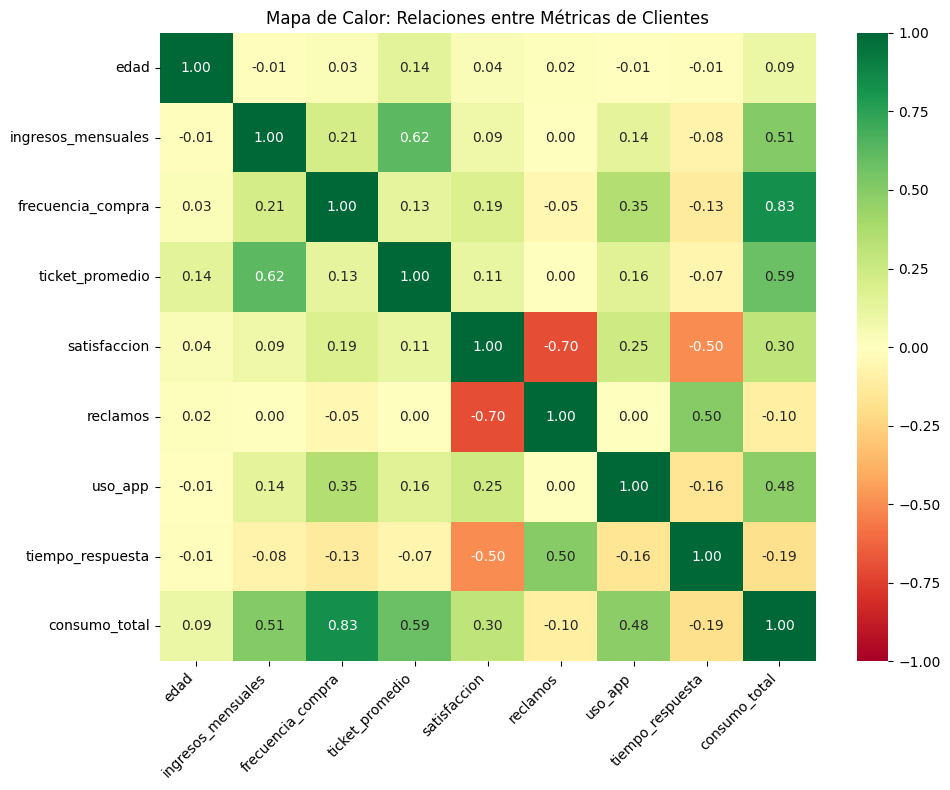

In [11]:
# 1. Calcular la matriz de correlación
matriz_corr = df_limpio_corr[variables_numericas].corr()

# Mostrar la matriz redondeada
print("--- Matriz de Correlación ---")
print(matriz_corr.round(2))

# 2. Generar el Mapa de Calor
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='RdYlGn', fmt=".2f", vmin=-1, vmax=1)
plt.title("Mapa de Calor: Relaciones entre Métricas de Clientes")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Explicación de Relaciones y Conclusiones Comerciales

**A) Correlaciones Positivas Más Importantes (2%)**
* `frecuencia_compra` y `consumo_total` (r = 0.83): Fuerte relación positiva.
* `ingresos_mensuales` y `ticket_promedio` (r = 0.63): Relación positiva considerable.

**B) Correlaciones Negativas Más Importantes (2%)**
* `reclamos` y `satisfaccion` (r = -0.71): Fuerte relación negativa.
* `tiempo_respuesta` y `satisfaccion` (r = -0.50): Relación negativa moderada.

**C) Explicación de 4 relaciones en Lenguaje de Negocio (2%)**
1. **Frecuencia de Compra vs Consumo Total (0.83):** Existe una correlación muy fuerte. Esto indica que la lealtad y la recurrencia son el principal motor de los ingresos de la empresa. Los clientes que regresan más veces a comprar son los que dejan el mayor volumen de dinero total, más allá de si compran cosas caras o baratas en una sola visita.
2. **Ingresos Mensuales vs Ticket Promedio (0.63):** A medida que aumentan los ingresos reportados por el cliente, tiende a gastar más por transacción (ticket promedio más alto). Tienen mayor poder adquisitivo y no dudan en adquirir productos premium o añadir más cosas al carrito en una sola compra.
3. **Reclamos vs Satisfacción (-0.71):** Una correlación negativa muy fuerte. Significa que, a mayor cantidad de reclamos interpuestos por un cliente, su nota de satisfacción cae drásticamente. El proceso de posventa actual no está revirtiendo el malestar; si un cliente tiene que reclamar, casi siempre terminará insatisfecho.
4. **Tiempo de Respuesta vs Satisfacción (-0.50):** Mientras más tarda la empresa en responder (tiempo de respuesta alto), menor es el nivel de satisfacción del cliente. Esto demuestra que la velocidad de atención al cliente es un pilar fundamental para la retención.

**D) Conclusiones y ayuda a la empresa (1%)**
Estos hallazgos permiten a la empresa enfocar sus recursos en dos frentes claros:
1. **Frente de Rentabilidad:** La empresa debe priorizar **programas de lealtad**. Como la frecuencia de compra impacta tan fuerte en el consumo total (0.83), regalar puntos o cupones de "próxima visita" será más rentable que intentar forzar a clientes de bajos ingresos a comprar productos caros.
2. **Frente de Retención:** La satisfacción del cliente está siendo destruida por los tiempos lentos y los reclamos constantes. La empresa necesita invertir urgentemente en **agilizar el departamento de soporte al cliente** (reducir el tiempo de respuesta), ya que cada minuto de retraso está costando puntos directos de satisfacción.